# Deep Learning Project

This notebook follows the requested steps:
1. Data loading
2. Data augmentation
3. Model configuration (Model 1)
4. Model training (Model 1)
5. Model configuration (Model 2)
6. Model training (Model 2)
7. Model configuration (Model 3)
8. Model training (Model 3)
9. Model evaluations
10. Combined plots (all three models)

In [ ]:
# Imports + environment settings
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import splitfolders
import sys
sys.path.append(os.path.abspath("..")) # Add the parent directory to the system path
from src.config import Config

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.initializers import HeUniform
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score, log_loss, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

def present_time() -> str:
    return datetime.now().strftime('%Y-%m-%d %H:%M:%S')

gpu_list = tf.config.list_physical_devices('GPU')
device = 'gpu' if gpu_list else 'cpu'
print(f'TensorFlow {tf.__version__} | GPUs: {gpu_list} | device: {device}')

TensorFlow 2.21.0 | GPUs: [] | device: cpu


In [2]:
# Reproducibility
seed_value = 7331
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

## 1) Data Loading

**What happens here**
- Set the project root and point to the image dataset folder.
- Define the class labels used throughout evaluation/plots.

**Tip**
- If `Total files in dataset` prints `0`, double-check `PROJECT_ROOT` and `dataset_path` before training.

In [3]:
# Paths (matches your original project structure)
PROJECT_ROOT = r'C:\Users\ashle\Project\Training\IBM\project'
os.chdir(PROJECT_ROOT)

data_dir = 'data'
dataset_path = os.path.join(data_dir, 'images_dataSAT')
agri_class_labels = ['non-agri', 'agri']

print('cwd:', os.getcwd())
print('dataset_path:', dataset_path)

cwd: C:\Users\ashle\Project\Training\IBM\project
dataset_path: data\images_dataSAT


In [4]:
# Dataset quick check
fnames = []
for dirname, _, filenames in os.walk(dataset_path):
    for filename in filenames:
        fnames.append(os.path.join(dirname, filename))

print(f'Total files in dataset: {len(fnames)}')
print('First 3:', fnames[:3])
print('Last 3:', fnames[-3:])

Total files in dataset: 6000
First 3: ['data\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_5902.jpg', 'data\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6074.jpg', 'data\\images_dataSAT\\class_0_non_agri\\tile_S2A_MSIL2A_20250409T105701_N0511_R094_T31UDQ_20250409T173716.SAFE_6246.jpg']
Last 3: ['data\\images_dataSAT\\class_1_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQD_20250427T170513.SAFE_0797.jpg', 'data\\images_dataSAT\\class_1_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQD_20250427T170513.SAFE_0805.jpg', 'data\\images_dataSAT\\class_1_agri\\tile_S2A_MSIL2A_20250427T101701_N0511_R065_T32UQD_20250427T170513.SAFE_0812.jpg']


Dataset Summary

In [5]:
# Dataset information summary
print('Dataset path:', dataset_path)
print('Total files:', len(fnames))

class_counts = {label: 0 for label in agri_class_labels}
for path in fnames:
    if os.path.sep + 'class_1_agri' + os.path.sep in path:
        class_counts['agri'] += 1
    else:
        class_counts['non-agri'] += 1

print('Class counts:', class_counts)

Dataset path: data\images_dataSAT
Total files: 6000
Class counts: {'non-agri': 3000, 'agri': 3000}


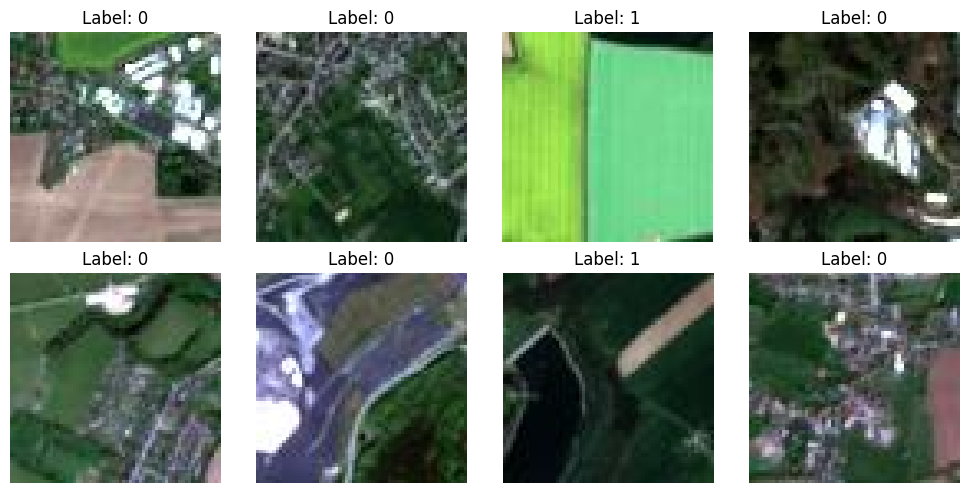

In [6]:
# Display a small grid of sample images with labels
num_images = 8
img_w, img_h = 64, 64
cols = 4
rows = int(np.ceil(num_images / cols))

sample_paths = random.sample(fnames, num_images)

plt.figure(figsize=(cols * 2.5, rows * 2.5))
for i, path in enumerate(sample_paths, start=1):
    img = tf.keras.utils.load_img(path, target_size=(img_w, img_h))
    img = tf.keras.utils.img_to_array(img) / 255.0

    label_idx = 1 if os.path.sep + 'class_1_agri' + os.path.sep in path else 0
    label = agri_class_labels[label_idx]

    plt.subplot(rows, cols, i)
    plt.imshow(img)
    plt.title(f'Label: {label_idx}')
    plt.axis('off')

plt.tight_layout()
plt.show()

Data Split

In [40]:

splitfolders.ratio(
    "data/images_dataSAT",
    output="data/images_split",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 6000 files [00:33, 178.45 files/s]


In [41]:
import os
from collections import Counter

base_dir = "data/images_split"

splits = ["train", "val", "test"]

summary = {}

for split in splits:
    split_path = os.path.join(base_dir, split)
    
    class_counts = {}
    total = 0
    
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        
        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            
            class_counts[class_name] = count
            total += count
    
    summary[split] = {
        "total": total,
        "classes": class_counts
    }

# Print summary
print("Dataset Split Summary")
print("="*40)

grand_total = sum(summary[s]["total"] for s in splits)

for split in splits:
    
    total = summary[split]["total"]
    percent = total / grand_total * 100
    
    print(f"\n{split.upper()} SET")
    print(f"Total images: {total} ({percent:.1f}%)")
    
    for class_name, count in summary[split]["classes"].items():
        print(f"  {class_name}: {count}")

Dataset Split Summary

TRAIN SET
Total images: 4200 (70.0%)
  class_0_non_agri: 2100
  class_1_agri: 2100

VAL SET
Total images: 900 (15.0%)
  class_0_non_agri: 450
  class_1_agri: 450

TEST SET
Total images: 900 (15.0%)
  class_0_non_agri: 450
  class_1_agri: 450


## 2) Data Augmentation

### Quick configuration sanity checks
Before training, it’s useful to confirm the labels and shapes match the model head:
- `train_gen_1.class_indices` should map your folders to `{0,1}` and align with `agri_class_labels` (index `0` → non‑agri, index `1` → agri).
- Model 1 should output shape `(batch, 1)` and use `binary_crossentropy`.
- Models 2 & 3 should output shape `(batch, 2)` and use `categorical_crossentropy`.
- The feature layer printed in Model 2/3 should have a 4D output `(None, H, W, C)` (this becomes $H\times W$ tokens).

**What happens here**
- Create two generators: one with augmentation (`datagen_aug`) and one clean (`datagen_eval`) for consistent evaluation.
- `make_generators(...)` returns `(train, val, pred)` iterators with a shared split setup.

**Why three generators?**
- Training uses augmentation to improve generalization.
- Validation uses the same preprocessing and split but no shuffling.
- Prediction/evaluation uses no augmentation so metrics are stable and comparable across models.

**Note on `class_mode`**
- Model 1 uses `binary` (sigmoid output).
- Models 2 & 3 use `categorical` (softmax output).

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Shared hyperparameters
img_w, img_h = 64, 64
n_channels = 3
batch_size = 32
epochs = 20

# Paths to split dataset
train_path = "data/images_split/train"
val_path   = "data/images_split/val"
test_path  = "data/images_split/test"

# Augmentation ONLY for training
datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# NO augmentation for validation and test
datagen_eval = ImageDataGenerator(rescale=1./255)


def make_generators(class_mode: str, batch_size_override=None, shuffle_train=True):

    bs = batch_size if batch_size_override is None else int(batch_size_override)

    # Training generator
    train_gen = datagen_train.flow_from_directory(
        train_path,
        target_size=(img_w, img_h),
        batch_size=bs,
        class_mode=class_mode,
        shuffle=shuffle_train
    )

    # Validation generator
    val_gen = datagen_eval.flow_from_directory(
        val_path,
        target_size=(img_w, img_h),
        batch_size=bs,
        class_mode=class_mode,
        shuffle=False
    )

    # Test generator (for ROC, evaluation)
    test_gen = datagen_eval.flow_from_directory(
        test_path,
        target_size=(img_w, img_h),
        batch_size=bs,
        class_mode=class_mode,
        shuffle=False
    )

    return train_gen, val_gen, test_gen

## 3) Model Configuration — Model 1 (CNN Base)

**Model 1 (CNN base)**
- A standard convolutional network trained end-to-end for binary classification.
- Uses an explicit `Input(...)` layer so the model has a well-defined input signature (important when reloading and when used as a backbone).
- Output is a single sigmoid probability for the positive class (`agri`).

**What to tweak first**
- `epochs1`: increase once the pipeline runs end-to-end.
- `lr1` / dropout: adjust if you see overfitting or slow learning.

In [8]:
lr1 = 1e-3
epochs1 = epochs
model1_name = 'model1_best.model.keras'

train_gen_1, val_gen_1, pred_gen_1 = make_generators(class_mode='binary')

model1 = Sequential([
    layers.Input(shape=(img_w, img_h, n_channels)),
    Conv2D(32, (5, 5), activation='relu', padding='same', strides=(1, 1), kernel_initializer=HeUniform()),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(64, (5, 5), activation='relu', padding='same', strides=(1, 1), kernel_initializer=HeUniform()),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(128, (5, 5), activation='relu', padding='same', strides=(1, 1), kernel_initializer=HeUniform()),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(256, (5, 5), activation='relu', padding='same', strides=(1, 1), kernel_initializer=HeUniform()),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(512, (5, 5), activation='relu', padding='same', strides=(1, 1), kernel_initializer=HeUniform()),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    Conv2D(1024, (5, 5), activation='relu', padding='same', strides=(1, 1), kernel_initializer=HeUniform()),
    MaxPooling2D(2, 2),
    BatchNormalization(),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu', kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    Dense(128, activation='relu', kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu', kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    Dense(512, activation='relu', kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1024, activation='relu', kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    Dense(2048, activation='relu', kernel_initializer=HeUniform()),
    BatchNormalization(),
    Dropout(0.4),

    Dense(1, activation='sigmoid'),
])

model1.compile(optimizer=Adam(learning_rate=lr1), loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()

Found 4200 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Found 900 images belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 1024)     │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 1, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 20,352,897 (77.64 MB)

 Trainable params: 20,340,801 (77.59 MB)

 Non-trainable params: 12,096 (47.25 KB)

## 4) Model Training — Model 1

**Training behavior**
- Trains Model 1 on the augmented training split and evaluates on the validation split each epoch.
- Saves the best checkpoint to `model1_best.model.keras` based on `val_accuracy`.

**Checkpoint note**
- The saved model is later reloaded as the CNN backbone for Models 2 and 3.

In [10]:
checkpoint1 = ModelCheckpoint(
    filepath=model1_name,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1,
)

print(f'[{present_time()}] Training Model 1...')
history1 = model1.fit(
    train_gen_1,
    epochs=epochs1,
    validation_data=val_gen_1,
    callbacks=[checkpoint1],
    verbose=1,
)

[2026-02-21 09:24:34] Training Model 1...
Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.7587 - loss: 0.7085
Epoch 1: val_accuracy improved from None to 0.33889, saving model to model1_best.model.keras

Epoch 1: finished saving model to model1_best.model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 110s 796ms/step - accuracy: 0.8607 - loss: 0.4670 - val_accuracy: 0.3389 - val_loss: 10.1907
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 982ms/step - accuracy: 0.9322 - loss: 0.2361
Epoch 2: val_accuracy improved from 0.33889 to 0.96556, saving model to model1_best.model.keras

Epoch 2: finished saving model to model1_best.model.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 131s 996ms/step - accuracy: 0.9436 - loss: 0.2006 - val_accuracy: 0.9656 - val_loss: 0.1439
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9534 - loss: 0.1561
Epoch 3: val_accuracy did not improve from 0.96556
132/132 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.9524 - loss: 0.1554 - val_accuracy: 0.95

## 5) Model Configuration — Model 2 (CNN → ViT Hybrid, Frozen CNN)

**Model 2 (CNN → Transformer hybrid, frozen CNN)**
- Reloads the trained CNN and extracts an intermediate 4D feature map $(H, W, C)$.
- Flattens the feature map into a token sequence of length $H\times W$ and applies positional embeddings + Transformer blocks.
- The CNN backbone is frozen here; only the Transformer head learns.

**Feature layer selection**
- The notebook auto-picks a valid 4D feature-map layer from the loaded CNN (layer names can change after save/load).
- It prints which layer was selected and its output shape so you can confirm the tokenization dimensions.

In [9]:
@tf.keras.utils.register_keras_serializable(package='Custom')
class AddPositionEmbedding(layers.Layer):
    def __init__(self, num_patches, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = int(num_patches)
        self.embed_dim = int(embed_dim)
        self.pos = self.add_weight(
            name='pos_embedding',
            shape=(1, self.num_patches, self.embed_dim),
            initializer='random_normal',
            trainable=True,
        )

    def call(self, tokens):
        return tokens + self.pos

    def get_config(self):
        config = super().get_config()
        config.update({'num_patches': self.num_patches, 'embed_dim': self.embed_dim})
        return config

@tf.keras.utils.register_keras_serializable(package='Custom')
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads=8, mlp_dim=2048, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = int(embed_dim)
        self.num_heads = int(num_heads)
        self.mlp_dim = int(mlp_dim)
        self.dropout = float(dropout)
        self.mha = layers.MultiHeadAttention(num_heads=self.num_heads, key_dim=self.embed_dim)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.mlp = tf.keras.Sequential([
            layers.Dense(self.mlp_dim, activation='gelu'),
            layers.Dropout(self.dropout),
            layers.Dense(self.embed_dim),
            layers.Dropout(self.dropout),
        ])

    def call(self, x):
        x = self.norm1(x + self.mha(x, x))
        return self.norm2(x + self.mlp(x))

    def get_config(self):
        config = super().get_config()
        config.update({
            'embed_dim': self.embed_dim,
            'num_heads': self.num_heads,
            'mlp_dim': self.mlp_dim,
            'dropout': self.dropout,
        })
        return config

def ensure_model_called(model, input_shape=(img_w, img_h, n_channels)):
    try:
        _ = model.input
        return model
    except Exception:
        pass
    dummy = tf.zeros((1,) + tuple(input_shape), dtype=tf.float32)
    _ = model(dummy, training=False)
    return model

def build_cnn_vit_hybrid(
    cnn_model,
    feature_layer_name,
    num_transformer_layers=4,
    num_heads=8,
    mlp_dim=2048,
    num_classes=1,
    fine_tune_cnn=False,
 ):
    cnn_model = ensure_model_called(cnn_model)
    cnn_model.trainable = bool(fine_tune_cnn)
    features = cnn_model.get_layer(feature_layer_name).output
    H, W, C = features.shape[1], features.shape[2], features.shape[3]
    if None in (H, W, C):
        raise ValueError(f'Backbone feature map has unknown shape: {features.shape}. Make sure the CNN input shape is fixed.')
    H, W, C = int(H), int(W), int(C)
    x = layers.Reshape((H * W, C))(features)
    x = AddPositionEmbedding(H * W, C)(x)
    for _ in range(int(num_transformer_layers)):
        x = TransformerBlock(C, num_heads=num_heads, mlp_dim=mlp_dim)(x)
    x = layers.GlobalAveragePooling1D()(x)
    out_units = int(num_classes)
    out_activation = 'sigmoid' if out_units == 1 else 'softmax'
    outputs = layers.Dense(out_units, activation=out_activation)(x)
    return Model(cnn_model.inputs, outputs, name='CNN_ViT_hybrid')

In [10]:
lr2 = 1e-4
epochs2 = epochs
model2_name = 'model2_cnn_vit_best.model.keras'

batch_size_2 = batch_size
train_gen_2, val_gen_2, pred_gen_2 = make_generators(class_mode='binary', batch_size_override=batch_size_2)

cnn_model_path = model1_name
cnn_model = load_model(cnn_model_path)
cnn_model = ensure_model_called(cnn_model)

feature_layer_name = "batch_normalization_5"
print('Using CNN feature layer:', feature_layer_name, '| output:', cnn_model.get_layer(feature_layer_name).output.shape)

model2 = build_cnn_vit_hybrid(
    cnn_model,
    feature_layer_name=feature_layer_name,
    num_transformer_layers=4,
    num_heads=8,
    mlp_dim=2048,
    num_classes=1,  # binary sigmoid head
    fine_tune_cnn=False,
 )

model2.compile(optimizer=Adam(learning_rate=lr2), loss='binary_crossentropy', metrics=['accuracy'])
model2.summary()

dummy = tf.random.normal([1, img_w, img_h, n_channels])
print('Model 2 logits shape:', model2(dummy).shape)

Found 4200 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Using CNN feature layer: batch_normalization_5 | output: (None, 1, 1, 1024)



Model: "CNN_ViT_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 1024)     │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 1, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 1024)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_position_embedding          │ (None, 1, 1024)        │         1,024 │
│ (AddPositionEmbedding)          │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 168,599,745 (643.16 MB)

 Trainable params: 151,128,065 (576.51 MB)

 Non-trainable params: 17,471,680 (66.65 MB)

Model 2 logits shape: (1, 1)


## 6) Model Training — Model 2

**Training notes (Model 2)**
- Uses a smaller batch size (`batch_size_2 = 4`) to reduce memory pressure (Transformer attention can be heavy).
- Checkpoint selects the best model by lowest `val_loss`.

**If you hit slow training**
- Reduce `num_transformer_layers` or `mlp_dim`, or increase `img_w/img_h` only after everything works.

In [13]:
checkpoint2 = ModelCheckpoint(
    filepath=model2_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1,
)

print(f'[{present_time()}] Training Model 2...')
history2 = model2.fit(
    train_gen_2,
    epochs=epochs2,
    validation_data=val_gen_2,
    callbacks=[checkpoint2],
    verbose=1,
)

[2026-02-21 10:05:20] Training Model 2...
Epoch 1/20
121/132 ━━━━━━━━━━━━━━━━━━━━ 2:55 16s/step - accuracy: 0.9786 - loss: 0.1270

KeyboardInterrupt: 

## 7) Model Configuration — Model 3 (CNN → ViT Hybrid, Fine-Tuned CNN)

**Model 3 (same hybrid, but fine-tunes the CNN)**
- Rebuilds the CNN→Transformer head, but sets `fine_tune_cnn=True` so CNN weights can update.
- This often improves accuracy, but increases training time and the risk of overfitting.

**Common approach**
- Train Model 2 first (frozen CNN), then fine-tune (Model 3) with a lower learning rate if needed.

In [11]:
lr3 = 1e-4
epochs3 = epochs
model3_name = 'model3_cnn_vit_tuned_best.model.keras'

batch_size_3 = batch_size
train_gen_3, val_gen_3, pred_gen_3 = make_generators(class_mode='binary', batch_size_override=batch_size_3)

cnn_model_path = model1_name
cnn_model_ft = load_model(cnn_model_path)
cnn_model_ft = ensure_model_called(cnn_model_ft)

feature_layer_name = "batch_normalization_5"
print('Using CNN feature layer:', feature_layer_name, '| output:', cnn_model_ft.get_layer(feature_layer_name).output.shape)

model3 = build_cnn_vit_hybrid(
    cnn_model_ft,
    feature_layer_name=feature_layer_name,
    num_transformer_layers=4,
    num_heads=8,
    mlp_dim=2048,
    num_classes=1,  # binary sigmoid head
    fine_tune_cnn=True,
 )

model3.compile(optimizer=Adam(learning_rate=lr3), loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

dummy = tf.random.normal([1, img_w, img_h, n_channels])
print('Model 3 logits shape:', model3(dummy).shape)

Found 4200 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Found 900 images belonging to 2 classes.
Using CNN feature layer: batch_normalization_5 | output: (None, 1, 1, 1024)


Model: "CNN_ViT_hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 256)      │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 512)      │     3,277,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2, 2, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 2, 2, 1024)     │    13,108,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 1, 1, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1, 1, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 1024)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_position_embedding_1        │ (None, 1, 1024)        │         1,024 │
│ (AddPositionEmbedding)          │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 168,599,745 (643.16 MB)

 Trainable params: 168,595,713 (643.14 MB)

 Non-trainable params: 4,032 (15.75 KB)

Model 3 logits shape: (1, 1)


## 8) Model Training — Model 3

**Training notes (Model 3)**
- Same training loop as Model 2, but now the CNN backbone is trainable.
- If validation degrades quickly, try a smaller `lr3` (e.g., `1e-5`) or fewer epochs.

In [ ]:
checkpoint3 = ModelCheckpoint(
    filepath=model3_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1,
)

print(f'[{present_time()}] Training Model 3...')
history3 = model3.fit(
    train_gen_3,
    epochs=epochs3,
    validation_data=val_gen_3,
    callbacks=[checkpoint3],
    verbose=1,
)

[2026-02-20 19:35:26] Training Model 3...
Epoch 1/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6969 - loss: 0.8511
Epoch 1: val_loss improved from None to 0.68868, saving model to model3_cnn_vit_tuned_best.model.keras

Epoch 1: finished saving model to model3_cnn_vit_tuned_best.model.keras
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1245s 1s/step - accuracy: 0.6112 - loss: 0.7543 - val_accuracy: 0.5492 - val_loss: 0.6887
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5519 - loss: 0.7147
Epoch 2: val_loss did not improve from 0.68868
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1217s 1s/step - accuracy: 0.5469 - loss: 0.7133 - val_accuracy: 0.5000 - val_loss: 0.6937
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5282 - loss: 0.7091
Epoch 3: val_loss did not improve from 0.68868
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1215s 1s/step - accuracy: 0.5433 - loss: 0.7031 - val_accuracy: 0.5000 - val_loss: 0.7267
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5

## 9) Model Evaluations

**Evaluation strategy (all models)**
- Uses the non-augmented `pred_gen_*` generator so results are deterministic and comparable.
- `collect_predictions(...)` normalizes outputs to a 2-column probability array so we can compute ROC-AUC consistently for sigmoid and softmax models.

**Metrics**
- Accuracy/Precision/Recall/F1 from hard predictions
- ROC-AUC from positive-class probabilities
- Log loss from predicted probabilities
- Confusion matrix for error analysis

In [12]:
def labels_from_generator(gen, fallback=None):
    if hasattr(gen, 'class_indices') and isinstance(gen.class_indices, dict) and len(gen.class_indices) > 0:
        inv = {v: k for k, v in gen.class_indices.items()}
        labels = [inv[i] for i in range(len(inv))]
        friendly = {
            'class_0_nonagri': 'non-agri',
            'class_0_non_agri': 'non-agri',
            'class_0_non-agri': 'non-agri',
            'class_1_agri': 'agri',
        }
        labels = [friendly.get(x, x) for x in labels]
        return labels
    return fallback

def collect_predictions(model, generator):
    y_true = generator.classes
    y_prob = model.predict(generator, verbose=1)
    y_prob = np.asarray(y_prob)

    # normalize to (n, 2)
    if y_prob.ndim == 1:
        y_prob = y_prob.reshape(-1, 1)
    if y_prob.shape[1] == 1:
        y_prob2 = np.hstack([1 - y_prob, y_prob])
    else:
        y_prob2 = y_prob

    y_pred = np.argmax(y_prob2, axis=1)
    return y_true, y_pred, y_prob2

def print_metrics(y_true, y_pred, y_prob2, class_labels, model_name):
    pos_prob = y_prob2[:, 1]
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, pos_prob),
        'Loss': log_loss(y_true, y_prob2),
    }
    print(f'\n=== {model_name} ===')
    for k, v in metrics.items():
        print(f'{k:>9}: {v:.4f}')
    print('\nDebug:')
    print('  y_true counts:', dict(zip(*np.unique(y_true, return_counts=True))))
    print('  y_pred counts:', dict(zip(*np.unique(y_pred, return_counts=True))))
    print(f'  pos_prob: min={pos_prob.min():.4f} mean={pos_prob.mean():.4f} max={pos_prob.max():.4f}')

    print('\nClassification report:')
    print(classification_report(y_true, y_pred, target_names=class_labels, digits=4, zero_division=0))
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(values_format='d')
    plt.title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.show()
    return metrics

In [16]:
model = 'model'
model_dir = os.path.join(PROJECT_ROOT, model)

path_1 = os.path.join(model_dir, model1_name)
path_2 = os.path.join(model_dir, model2_name)
path_3 = os.path.join(model_dir, model3_name)

print("model_dir:", model_dir)
print("path_1:", path_1)
print("path_2:", path_2)
print("path_3:", path_3)

model_dir: C:\Users\ashle\Project\Training\IBM\project\model
path_1: C:\Users\ashle\Project\Training\IBM\project\model\model1_best.model.keras
path_2: C:\Users\ashle\Project\Training\IBM\project\model\model2_cnn_vit_best.model.keras
path_3: C:\Users\ashle\Project\Training\IBM\project\model\model3_cnn_vit_tuned_best.model.keras


c:\Users\ashle\Project\Training\venv_311\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'transformer_block', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\ashle\Project\Training\venv_311\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `build()` was called on layer 'transformer_block_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
c:\Users\ashle\Project\Training\venv_311\Lib\site-packages\keras\src\layers\layer.py:424: UserWarning: `

Best checkpoint models loaded successfully.
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step

=== Model 1 (CNN base) ===
 Accuracy: 0.9989
Precision: 0.9978
   Recall: 1.0000
       F1: 0.9989
  ROC-AUC: 1.0000
     Loss: 0.0065

Debug:
  y_true counts: {0: 450, 1: 450}
  y_pred counts: {0: 449, 1: 451}
  pos_prob: min=0.0000 mean=0.4976 max=1.0000

Classification report:
              precision    recall  f1-score   support

    non-agri     1.0000    0.9978    0.9989       450
        agri     0.9978    1.0000    0.9989       450

    accuracy                         0.9989       900
   macro avg     0.9989    0.9989    0.9989       900
weighted avg     0.9989    0.9989    0.9989       900



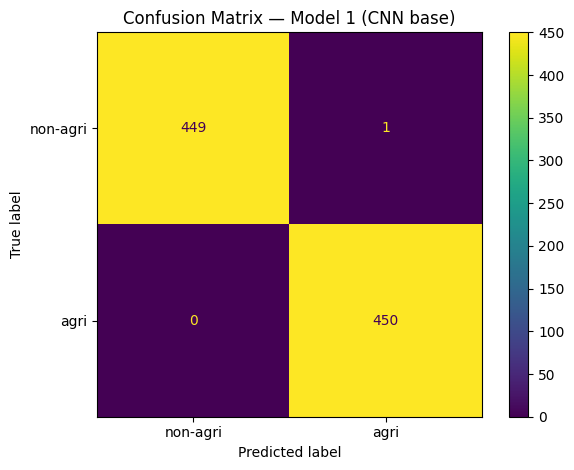

29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 294ms/step

=== Model 2 (CNN→ViT frozen) ===
 Accuracy: 0.9978
Precision: 1.0000
   Recall: 0.9956
       F1: 0.9978
  ROC-AUC: 1.0000
     Loss: 0.0074

Debug:
  y_true counts: {0: 450, 1: 450}
  y_pred counts: {0: 452, 1: 448}
  pos_prob: min=0.0000 mean=0.4972 max=0.9995

Classification report:
              precision    recall  f1-score   support

    non-agri     0.9956    1.0000    0.9978       450
        agri     1.0000    0.9956    0.9978       450

    accuracy                         0.9978       900
   macro avg     0.9978    0.9978    0.9978       900
weighted avg     0.9978    0.9978    0.9978       900



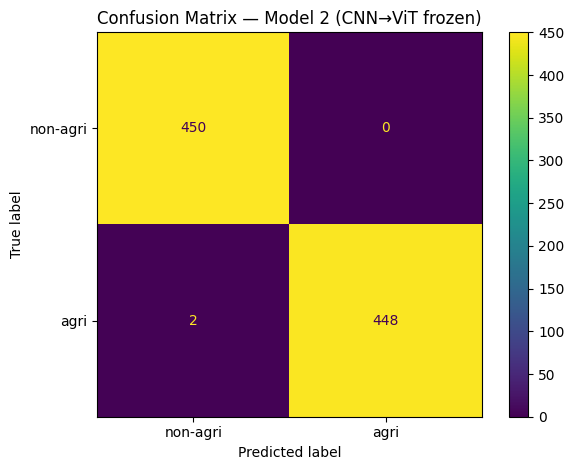

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 182ms/step

=== Model 3 (CNN→ViT fine-tuned) ===
 Accuracy: 0.9989
Precision: 0.9978
   Recall: 1.0000
       F1: 0.9989
  ROC-AUC: 1.0000
     Loss: 0.0036

Debug:
  y_true counts: {0: 450, 1: 450}
  y_pred counts: {0: 449, 1: 451}
  pos_prob: min=0.0000 mean=0.4989 max=1.0000

Classification report:
              precision    recall  f1-score   support

    non-agri     1.0000    0.9978    0.9989       450
        agri     0.9978    1.0000    0.9989       450

    accuracy                         0.9989       900
   macro avg     0.9989    0.9989    0.9989       900
weighted avg     0.9989    0.9989    0.9989       900



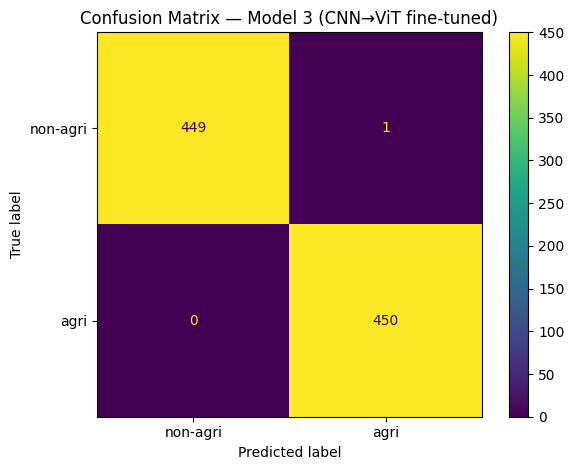

{'Model 1': {'Accuracy': 0.9988888888888889,
  'Precision': 0.9977827050997783,
  'Recall': 1.0,
  'F1': 0.9988901220865705,
  'ROC-AUC': 0.9999753086419753,
  'Loss': 0.006471801047322856},
 'Model 2': {'Accuracy': 0.9977777777777778,
  'Precision': 1.0,
  'Recall': 0.9955555555555555,
  'F1': 0.9977728285077951,
  'ROC-AUC': 0.9999901234567901,
  'Loss': 0.007361670592870321},
 'Model 3': {'Accuracy': 0.9988888888888889,
  'Precision': 0.9977827050997783,
  'Recall': 1.0,
  'F1': 0.9988901220865705,
  'ROC-AUC': 1.0,
  'Loss': 0.0035818409709866576}}

In [17]:
# ================================
# Load BEST saved models
# ================================

model1 = load_model(path_1)

model2 = load_model(
    path_2,
    custom_objects={
        "AddPositionEmbedding": AddPositionEmbedding,
        "TransformerBlock": TransformerBlock,
    }
)

model3 = load_model(
    path_3,
    custom_objects={
        "AddPositionEmbedding": AddPositionEmbedding,
        "TransformerBlock": TransformerBlock,
    }
)

print("Best checkpoint models loaded successfully.")


# ================================
# Collect predictions from TEST generators
# ================================

labels1 = labels_from_generator(pred_gen_1, agri_class_labels)
y1_true, y1_pred, y1_prob2 = collect_predictions(model1, pred_gen_1)
m1 = print_metrics(y1_true, y1_pred, y1_prob2, labels1, 'Model 1 (CNN base)')

labels2 = labels_from_generator(pred_gen_2, agri_class_labels)
y2_true, y2_pred, y2_prob2 = collect_predictions(model2, pred_gen_2)
m2 = print_metrics(y2_true, y2_pred, y2_prob2, labels2, 'Model 2 (CNN→ViT frozen)')

labels3 = labels_from_generator(pred_gen_3, agri_class_labels)
y3_true, y3_pred, y3_prob2 = collect_predictions(model3, pred_gen_3)
m3 = print_metrics(y3_true, y3_pred, y3_prob2, labels3, 'Model 3 (CNN→ViT fine-tuned)')


# ================================
# Summary
# ================================
summary = {'Model 1': m1, 'Model 2': m2, 'Model 3': m3}
summary

In [25]:
# ================================
# Convert summary dictionary to DataFrame
# ================================

df_results = pd.DataFrame(summary).T

# Optional: reorder columns nicely
df_results = df_results[
    ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Loss']
]

# Round values for clean display
df_results = df_results.round(4)

# Display DataFrame
df_results

,Accuracy,Precision,Recall,F1,ROC-AUC,Loss
Model 1,0.9989,0.9978,1.0000,0.9989,1.0,0.0065
Model 2,0.9978,1.0000,0.9956,0.9978,1.0,0.0074
Model 3,0.9989,0.9978,1.0000,0.9989,1.0,0.0036


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices_row(results, class_labels):
    """
    results: list of tuples -> [(model_name, y_true, y_pred), ...]
    class_labels: list of class names
    """
    
    n = len(results)
    
    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    
    # If only one model, make axes iterable
    if n == 1:
        axes = [axes]
    
    for ax, (model_name, y_true, y_pred) in zip(axes, results):
        
        cm = confusion_matrix(y_true, y_pred)
        
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_labels
        )
        
        disp.plot(ax=ax, values_format='d', colorbar=False)
        ax.set_title(model_name)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    
    plt.suptitle("Confusion Matrices Comparison", fontsize=14)
    plt.tight_layout()
    plt.show()

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrices_row(results, class_labels):
    
    n = len(results)
    
    fig, axes = plt.subplots(
        1, n,
        figsize=(4*n, 4),                # slightly smaller width
        gridspec_kw={'wspace': 0.25}    # reduce horizontal spacing
    )
    
    if n == 1:
        axes = [axes]
    
    for ax, (model_name, y_true, y_pred) in zip(axes, results):
        
        cm = confusion_matrix(y_true, y_pred)
        
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_labels
        )
        
        disp.plot(ax=ax, values_format='d', colorbar=False)
        
        ax.set_title(model_name, fontsize=11)
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
    
    # reduce margins further
    plt.subplots_adjust(wspace=0.25, left=0.05, right=0.98)
    
    plt.suptitle("Confusion Matrices Comparison", fontsize=14)
    plt.show()

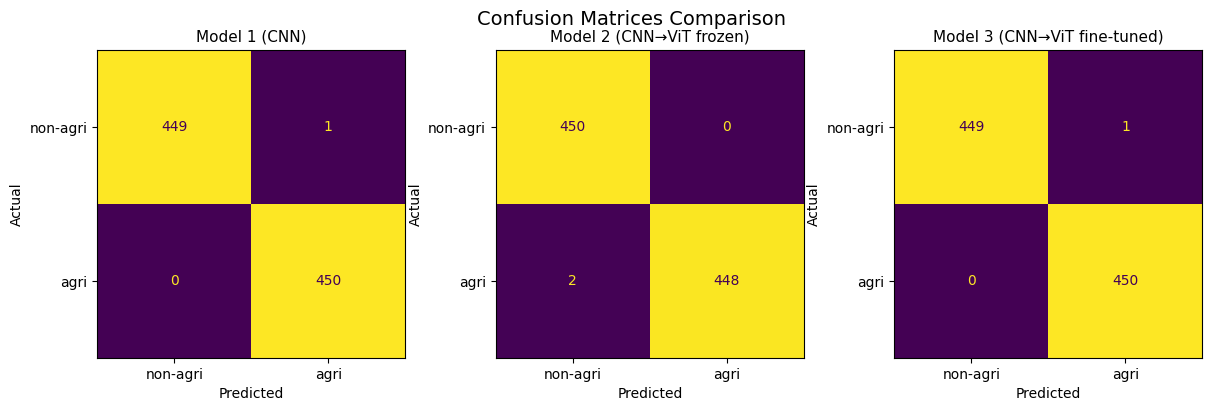

In [39]:
results = [
    ("Model 1 (CNN)", y1_true, y1_pred),
    ("Model 2 (CNN→ViT frozen)", y2_true, y2_pred),
    ("Model 3 (CNN→ViT fine-tuned)", y3_true, y3_pred),
]

plot_confusion_matrices_row(results, agri_class_labels)

## 10) Combined Plots (All Three Models)

**Combined plots**
- Overlays training histories (accuracy and loss) for Models 1–3 on shared axes.
- Plots all ROC curves together so you can compare separability at a glance.

**Reading the plots**
- Diverging train vs val curves → likely overfitting
- ROC closer to top-left and higher AUC → better discrimination

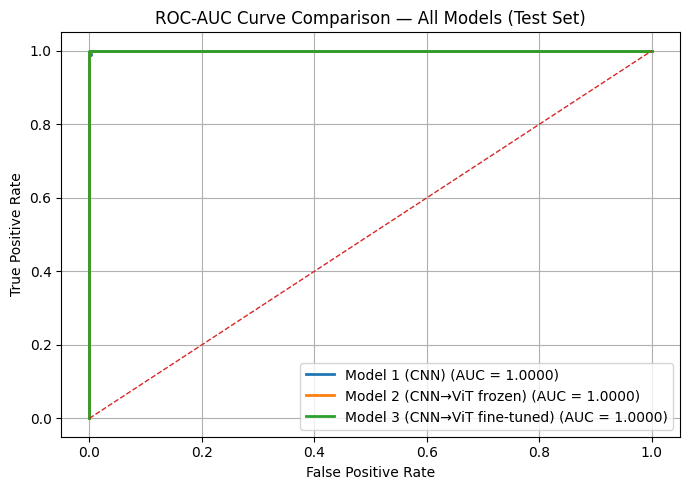

In [22]:
# ================================
# Plot ROC curves for all models
# ================================

plt.figure(figsize=(7, 5))

models_data = [
    ("Model 1 (CNN)", y1_true, y1_prob2),
    ("Model 2 (CNN→ViT frozen)", y2_true, y2_prob2),
    ("Model 3 (CNN→ViT fine-tuned)", y3_true, y3_prob2),
]

for name, y_true, y_prob2 in models_data:
    
    # positive class probability (agri class)
    pos_prob = y_prob2[:, 1]
    
    # compute ROC
    fpr, tpr, _ = roc_curve(y_true, pos_prob)
    auc_score = roc_auc_score(y_true, pos_prob)
    
    # plot curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

# diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

# labels and formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison — All Models (Test Set)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()